# Stateful Strategy Patterns

**Docker image**: `ml4t`

This notebook shows when a sequential backtest is the clearest representation
of a trading strategy.
In this chapter, "vectorized" means expressing the strategy as precomputed
aligned arrays such as signals, ranks, target weights, or cost estimates.
"Sequential" means evaluating the strategy bar by bar while carrying mutable
state such as positions, realized P&L, equity, or pending orders.

Many strategies can be written either way. If the full trading protocol can be
defined in advance, the array-based approach is attractive because it is fast
and broadcasts naturally across parameter grids, at the cost of materializing
larger intermediate objects in memory. A sequential engine earns its keep when
later decisions depend on earlier execution outcomes or on broker state that
is awkward to encode as a fixed matrix.

That difference is also one of description. Trading itself has a loop-like
character: observe the market, update state, decide, execute, and repeat.
Array-based backtests compress that loop into aligned matrices. This buys speed
and broad parameter sweeps, but it also makes the logic more abstract and can
make mistakes harder to spot when timing, fills, or state transitions are not
written down explicitly. Sequential backtests stay closer to the way the
strategy would be described to a trader or implemented in a live system.

## The Core Distinction

Array-based: compute `signals[t]`, `weights[t]`, or `orders[t]` from observed
data and predetermined rules, then apply the portfolio update.

Sequential: update `action[t]` from observed data plus evolving state, for
example `action[t] = g(data[0:t], positions[t-1], fills[0:t-1], equity[t-1])`.

This notebook uses `ml4t-backtest` for the sequential implementation. The
examples are meant to show when explicit state is useful, not to claim that
another framework can never reproduce the same protocol.

## Three Patterns Demonstrated

| Pattern | Why sequential state is a natural fit |
|---------|---------------------------------------|
| **Adaptive Kelly Sizing** | Position size depends on realized trade outcomes, so sizing becomes a recursive update rather than a fixed weight matrix |
| **Pairs Trading** | The two legs share cash, margin, and fill coordination, which is easier to reason about when state is explicit |
| **Drawdown Circuit Breaker** | Exposure changes with the realized equity path, so future actions depend on prior portfolio evolution |

**Learning Objectives:**
1. Distinguish array-based backtests from sequential stateful simulation.
2. Implement strategies whose rules depend on prior fills, positions, or equity.
3. Judge when the extra flexibility of sequential simulation is worth the cost.

**Book Reference:** Chapter 16, Section 16.3 - when event-driven simulation is
the clearest representation of a trading strategy.

**Prerequisites:** [`04_single_asset_ml4t_backtest`](04_single_asset_ml4t_backtest.ipynb) for the
`ml4t-backtest` API (Engine, Strategy, DataFeed).

**Library Reference:** See the [Stateful Strategies](https://github.com/stefan-jansen/ml4t-backtest/blob/main/docs/user-guide/stateful-strategies.md)
guide for all five pattern categories and the broker state API.

## Setup

In [1]:
from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import ShareType
from plotly.subplots import make_subplots

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

In [2]:
# Production defaults - Papermill injects overrides after this cell
N_BARS = 500
SEED = 42

In [3]:
set_global_seeds(SEED)

## Data: Real ETF Bars from `load_etfs`

Each pattern uses a real ETF window chosen for the stateful behavior it
exercises. The data path is the same as the sibling Ch16 notebooks
(`load_etfs` returns daily OHLCV for the publication universe). Three
windows are loaded on demand inside each section below.

In [4]:
def _load_single_window(symbol: str, start: str, n_bars: int) -> pl.DataFrame:
    """Load the first ``n_bars`` daily OHLCV bars for ``symbol`` from ``start``.

    Returns a stacked Polars DataFrame with the timestamp/symbol/OHLCV schema
    expected by ``DataFeed`` (datetime-typed timestamp for engine compatibility).
    """
    df = (
        load_etfs()
        .filter((pl.col("symbol") == symbol) & (pl.col("timestamp") >= pl.lit(start).str.to_date()))
        .sort("timestamp")
        .head(n_bars)
        .with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
    )
    if df.height < n_bars:
        raise ValueError(
            f"load_etfs returned {df.height} bars for {symbol} from {start}; need {n_bars}"
        )
    result = df.select(["timestamp", "symbol", "open", "high", "low", "close", "volume"])
    assert result.n_unique(["symbol", "timestamp"]) == len(result)
    assert result["symbol"].unique().to_list() == [symbol]
    return result

Pairs require a second loader that keeps only timestamps observed for both
symbols before truncating the common window.

In [5]:
def _load_pair_window(symbol_a: str, symbol_b: str, start: str, n_bars: int) -> pl.DataFrame:
    """Load aligned daily OHLCV for two symbols, restricted to common timestamps.

    Both legs are truncated to the first ``n_bars`` shared trading days.
    """
    raw = (
        load_etfs()
        .filter(
            pl.col("symbol").is_in([symbol_a, symbol_b])
            & (pl.col("timestamp") >= pl.lit(start).str.to_date())
        )
        .sort(["timestamp", "symbol"])
        .with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
    )
    # Inner-join the two legs on timestamp so the panel is bar-aligned.
    counts = raw.group_by("timestamp").len()
    shared = counts.filter(pl.col("len") == 2)["timestamp"]
    panel = raw.join(
        counts.filter(pl.col("len") == 2).select("timestamp"), on="timestamp", how="semi"
    ).sort(["timestamp", "symbol"])
    # First n_bars timestamps with both legs present.
    shared_sorted = sorted(shared.to_list())[:n_bars]
    if len(shared_sorted) < n_bars:
        raise ValueError(
            f"Only {len(shared_sorted)} aligned bars for {symbol_a}/{symbol_b} "
            f"from {start}; need {n_bars}"
        )
    result = panel.filter(pl.col("timestamp").is_in(shared_sorted)).select(
        ["timestamp", "symbol", "open", "high", "low", "close", "volume"]
    )
    assert result.n_unique(["symbol", "timestamp"]) == len(result)
    assert sorted(result["symbol"].unique().to_list()) == sorted([symbol_a, symbol_b])
    assert result.group_by("symbol").len()["len"].unique().to_list() == [n_bars]
    return result

### Signal Generator

Generate momentum, random, or alternating signals for the loaded prices.

In [6]:
def make_signals(
    prices: pl.DataFrame,
    signal_fn: str = "momentum",
    lookback: int = 20,
    seed: int = 42,
) -> pl.DataFrame:
    """Generate momentum, seeded random, or alternating signals."""
    parts = []
    for asset in prices["symbol"].unique().to_list():
        asset_df = prices.filter(pl.col("symbol") == asset).sort("timestamp")
        close = asset_df["close"]

        if signal_fn == "momentum":
            signal = (close / close.shift(lookback) - 1).fill_null(0.0)
        elif signal_fn == "random":
            asset_seed = seed + sum(ord(c) for c in asset)
            signal = pl.Series(np.random.default_rng(asset_seed).uniform(-1, 1, len(close)))
        elif signal_fn == "alternating":
            vals = np.zeros(len(close))
            for i in range(len(close)):
                vals[i] = 1.0 if (i // lookback) % 2 == 0 else -1.0
            signal = pl.Series(vals)
        else:
            raise ValueError(f"Unknown signal_fn: {signal_fn}")

        parts.append(
            pl.DataFrame(
                {
                    "timestamp": asset_df["timestamp"],
                    "symbol": asset_df["symbol"],
                    "signal": signal,
                }
            )
        )

    return pl.concat(parts).sort(["timestamp", "symbol"])

## Pattern 1: Adaptive Kelly Sizing (Feedback Loop)

**The idea**: Position size at each entry adapts based on the realized win rate
and payoff ratio from prior trades. The feedback loop:

```
position_size → P&L → Kelly_fraction → next_position_size
```

**Why a fixed matrix is awkward**: The Kelly fraction at bar N depends on trade
outcomes from bars 0..N-1, but those outcomes were themselves shaped by earlier
Kelly sizes. The rule is naturally recursive. You can code that recursion, but
not as a single precomputed signal matrix.

### Kelly Formula

The Kelly criterion determines the optimal fraction of capital to risk:

$$f^* = W - \frac{1 - W}{R}$$

where $W$ = win rate and $R$ = average win / average loss.
We use **half-Kelly**, meaning half the fraction the formula returns, for safety.

The sizing helper reads only realized P&L events available from the broker at
the current decision time. It returns the base target until both wins and
losses provide enough evidence for the half-Kelly update.

In [7]:
def _kelly_size(self, broker, asset):
    """Compute a bounded half-Kelly target from prior realized trades."""
    stats = broker.get_asset_stats(asset)
    if stats.total_trades < self.min_trades:
        return self.base_size

    wins = [pnl for pnl in stats.recent_pnls if pnl > 0]
    losses = [pnl for pnl in stats.recent_pnls if pnl <= 0]
    if not wins or not losses:
        return self.base_size

    avg_win = sum(wins) / len(wins)
    avg_loss = abs(sum(losses) / len(losses))
    if avg_loss == 0:
        return self.max_size

    payoff_ratio = avg_win / avg_loss
    full_kelly = stats.recent_win_rate - (1 - stats.recent_win_rate) / payoff_ratio
    fractional_kelly = max(0.0, full_kelly) * self.kelly_fraction
    return max(self.min_size, min(self.max_size, fractional_kelly))

The event callback records the target at each entry decision and submits it for
next-bar execution. Exits use the same lagged execution contract.

In [8]:
def _kelly_on_data(self, timestamp, data, context, broker):
    for asset, bar in data.items():
        signals = bar.get("signals", {})
        signal = signals.get(self.signal_column, 0) if signals else 0
        signal = 0 if signal is None else signal
        if bar.get("close", 0) <= 0:
            continue

        position = broker.get_position(asset)
        if position is None and signal > self.entry_threshold:
            size_fraction = self._kelly_size(broker, asset)
            self.size_history.append(size_fraction)
            self.entry_times.append(timestamp)
            broker.order_target_percent(asset, size_fraction)
        elif position is not None and signal < self.exit_threshold:
            broker.close_position(asset)

The strategy object holds the mutable history while delegating each step to
the two small helpers above.

In [9]:
class AdaptiveKellySizingStrategy(Strategy):
    """Position size adapts based on realized win rate and payoff ratio."""

    _kelly_size = _kelly_size
    on_data = _kelly_on_data

    def __init__(
        self,
        signal_column: str = "signal",
        entry_threshold: float = 0.01,
        exit_threshold: float = -0.01,
        base_size: float = 0.10,
        min_size: float = 0.02,
        max_size: float = 0.25,
        kelly_fraction: float = 0.5,
        min_trades: int = 5,
    ):
        self.signal_column = signal_column
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold
        self.base_size = base_size
        self.min_size = min_size
        self.max_size = max_size
        self.kelly_fraction = kelly_fraction
        self.min_trades = min_trades
        self.size_history: list[float] = []
        self.entry_times: list[datetime] = []

### Run Kelly Strategy

We use QQQ daily bars from 2018-01 through 2019-12 (500 trading days). The
window covers the Q4 2018 correction and the subsequent 2019 recovery, so
the realized win rate and payoff ratio shift enough to exercise the Kelly
feedback loop.

In [10]:
prices = _load_single_window(symbol="QQQ", start="2018-01-01", n_bars=N_BARS)
signals = make_signals(prices, signal_fn="momentum", lookback=20, seed=SEED)
KELLY_SYMBOL = "QQQ"

config = BacktestConfig(
    initial_cash=100_000,
    commission_rate=0.001,
    slippage_rate=0.0005,
    execution_mode=ExecutionMode.NEXT_BAR,
    share_type=ShareType.FRACTIONAL,
    calendar="NYSE",
)

# Kelly strategy
kelly_strategy = AdaptiveKellySizingStrategy(
    entry_threshold=0.02,
    exit_threshold=-0.01,
    base_size=0.10,
    min_size=0.02,
    max_size=0.25,
    kelly_fraction=0.5,
    min_trades=3,
)

feed = DataFeed(prices_df=prices, signals_df=signals)
engine = Engine(feed=feed, strategy=kelly_strategy, config=config)
kelly_result = engine.run()

**Adaptive Kelly sizing - backtest summary:**

In [11]:
m = kelly_result.metrics
pl.DataFrame(
    {
        "metric": [
            "Total return (%)",
            "Sharpe ratio",
            "Max drawdown (%)",
            "Total trades",
            "Win rate (%)",
        ],
        "value": [
            float(m["total_return_pct"]),
            float(m["sharpe"]),
            float(m["max_drawdown_pct"]),
            float(m["num_trades"]),
            float(m.get("win_rate", 0) * 100),
        ],
    }
)

metric,value
str,f64
"""Total return (%)""",-0.552918
"""Sharpe ratio""",-0.414066
"""Max drawdown (%)""",1.53411
"""Total trades""",10.0
"""Win rate (%)""",20.0


The output below reports the realized range of signal-time target fractions. It distinguishes an
active feedback loop from a strategy that merely contains adaptive code but never exercises it.

### Visualize Position Size Adaptation

The key observable: position sizes change over time as the strategy learns
from its own trade outcomes.

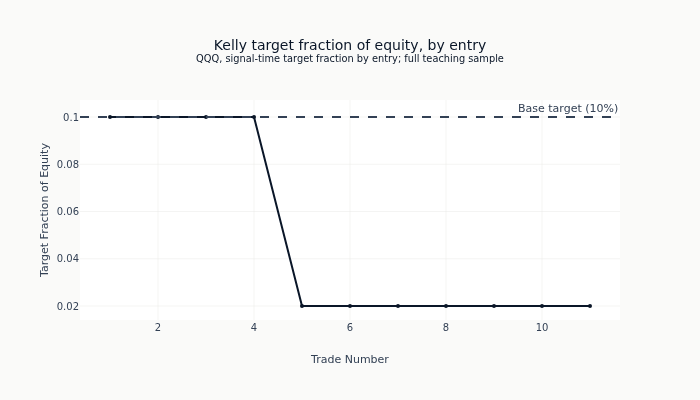

In [12]:
if kelly_strategy.size_history:
    trade_numbers = np.arange(1, len(kelly_strategy.size_history) + 1)
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=trade_numbers,
            y=kelly_strategy.size_history,
            mode="lines+markers",
            name="Adaptive target",
            line=dict(color=COLORS["blue"]),
            marker=dict(size=4),
        )
    )
    fig.add_hline(
        y=kelly_strategy.base_size,
        line_dash="dash",
        line_color=COLORS["neutral"],
        annotation_text=f"Base target ({kelly_strategy.base_size:.0%})",
    )
    fig.update_layout(
        title=(
            "Kelly target fraction of equity, by entry"
            "<br><sup>QQQ, signal-time target fraction by entry; full teaching sample</sup>"
        ),
        xaxis_title="Trade Number",
        yaxis_title="Target Fraction of Equity",
        height=400,
    )
    # A prefix count, not a total: the helper can return the base again later.
    show_plotly_with_alt(
        fig,
        (
            "Line chart of the Kelly target fraction of equity against trade number, one point per "
            "entry in the order the trades were taken, with a dashed horizontal line at the "
            "configured base target. The sizing helper returns the base target until enough "
            "trades have closed to estimate a win rate and a payoff ratio, and until the closed "
            "trades include both a win and a loss; past that point the Kelly formula sets the "
            "fraction. Drawn against trade number rather than date because the sizing changes on "
            "trade events, not on the calendar."
        ),
    )

In [13]:
kelly_size_min = min(kelly_strategy.size_history)
kelly_size_max = max(kelly_strategy.size_history)
kelly_size_mean = float(np.mean(kelly_strategy.size_history))
kelly_adapted_entries = sum(
    not np.isclose(size, kelly_strategy.base_size) for size in kelly_strategy.size_history
)
display(
    Markdown(
        f"The rule changes its target on **{kelly_adapted_entries} of "
        f"{len(kelly_strategy.size_history)} entry submissions**. Targets range from "
        f"**{kelly_size_min:.1%} to {kelly_size_max:.1%}** and average "
        f"**{kelly_size_mean:.1%}**, compared with the {kelly_strategy.base_size:.0%} base."
    )
)

The rule changes its target on **7 of 11 entry submissions**. Targets range from **2.0% to 10.0%** and average **4.9%**, compared with the 10% base.

### Compare to Fixed-Size Baseline

To see the impact of adaptive sizing, run the same signals at the fixed base fraction.

In [14]:
class FixedSizeStrategy(Strategy):
    """Baseline: always uses fixed position size (no adaptation)."""

    def __init__(self, size=0.10, entry_threshold=0.02, exit_threshold=-0.01):
        self.size = size
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold

    def on_data(self, timestamp, data, context, broker):
        for asset, bar in data.items():
            signals = bar.get("signals", {})
            signal = signals.get("signal", 0) if signals else 0
            if signal is None:
                signal = 0
            price = bar.get("close", 0)
            if price <= 0:
                continue

            position = broker.get_position(asset)
            if position is None and signal > self.entry_threshold:
                broker.order_target_percent(asset, self.size)
            elif position is not None and signal < self.exit_threshold:
                broker.close_position(asset)


fixed_strategy = FixedSizeStrategy(size=0.10, entry_threshold=0.02, exit_threshold=-0.01)
feed_fixed = DataFeed(prices_df=prices, signals_df=signals)
engine_fixed = Engine(feed=feed_fixed, strategy=fixed_strategy, config=config)
fixed_result = engine_fixed.run()

**Adaptive Kelly vs fixed-size baseline** - same signals, different sizing rule:

In [15]:
fm = fixed_result.metrics
pl.DataFrame(
    {
        "metric": ["Total return (%)", "Sharpe ratio", "Max drawdown (%)", "Total trades"],
        "adaptive_kelly": [
            float(m["total_return_pct"]),
            float(m["sharpe"]),
            float(m["max_drawdown_pct"]),
            float(m["num_trades"]),
        ],
        "fixed_10pct": [
            float(fm["total_return_pct"]),
            float(fm["sharpe"]),
            float(fm["max_drawdown_pct"]),
            float(fm["num_trades"]),
        ],
    }
)

metric,adaptive_kelly,fixed_10pct
str,f64,f64
"""Total return (%)""",-0.552918,0.670566
"""Sharpe ratio""",-0.414066,0.300955
"""Max drawdown (%)""",1.53411,1.53411
"""Total trades""",10.0,10.0


In [16]:
kelly_return = float(m["total_return_pct"])
fixed_return = float(fm["total_return_pct"])
kelly_trades = int(m["num_trades"])
fixed_trades = int(fm["num_trades"])
assert kelly_trades == fixed_trades
kelly_leader = "Adaptive Kelly" if kelly_return > fixed_return else "Fixed 10% sizing"
display(
    Markdown(
        f"**{kelly_leader}** has the higher full-sample return: "
        f"**{kelly_return:.2f}%** for adaptive sizing versus **{fixed_return:.2f}%** for the "
        f"fixed rule. Both use the same signals and complete **{kelly_trades} closed "
        "trades**, so the comparison isolates the recursive sizing decisions in this sample."
    )
)

**Fixed 10% sizing** has the higher full-sample return: **-0.55%** for adaptive sizing versus **0.67%** for the fixed rule. Both use the same signals and complete **10 closed trades**, so the comparison isolates the recursive sizing decisions in this sample.

**Key observation**: Both strategies see the same entry and exit signals, but
Kelly updates exposure from realized outcomes. After a losing streak it reduces
size; after a winning streak it can rebuild size. That recursive state update
is straightforward in a sequential engine and awkward to express as a static
array calculation.

## Pattern 2: Pairs Trading (Contingent Multi-Leg Execution)

**The idea**: Trade the spread between two correlated assets, but stage the pair
entry. The strategy opens the lead leg first, waits to observe the realized fill,
and then sizes the hedge from the actual filled notional rather than from an
idealized target weight.

**Why a fixed matrix is awkward**: The spread signal is easy to precompute, but
the trade management is contingent. The hedge size depends on the realized lead
leg quantity and entry price, both of which are outputs of the simulation. If
the hedge cannot be established quickly, the lead leg should be unwound rather
than treated as a valid standalone trade.

### Spread Trading Logic

1. Compute the rolling z-score of the price ratio B/A
2. Above the entry threshold: open the long A lead leg, then hedge with short B
3. Below the negative entry threshold: open the long B lead leg, then hedge with short A
4. Size the hedge from the realized lead-leg fill, not the intended target
5. Inside the exit band, or when the hedge cannot be completed, exit the pair

These small state helpers keep lead entry, hedge sizing, and reset behavior
visible as separate transitions.

In [17]:
def _reset_pair_state(self) -> None:
    self.pair_status = "flat"
    self.lead_asset = None
    self.hedge_asset = None
    self.pending_bars = 0

In [18]:
def _start_pair(self, long_asset: str, short_asset: str, long_price: float, broker) -> None:
    shares = broker.get_account_value() * self.position_size / long_price
    if shares <= 0:
        return
    broker.submit_order(long_asset, shares)
    self.lead_asset = long_asset
    self.hedge_asset = short_asset
    self.pair_status = "waiting_for_lead_fill"
    self.pending_bars = 0

In [19]:
def _submit_hedge(self, short_price: float, broker) -> None:
    if self.lead_asset is None or self.hedge_asset is None:
        return
    lead_position = broker.get_position(self.lead_asset)
    if lead_position is None or lead_position.quantity <= 0:
        return

    realized_notional = abs(lead_position.quantity) * lead_position.entry_price
    hedge_shares = realized_notional / short_price
    if hedge_shares <= 0:
        return
    broker.submit_order(self.hedge_asset, -hedge_shares)
    self.pair_status = "waiting_for_hedge_fill"
    self.pending_bars = 0

The z-score uses only the trailing ratio history through the current close.

In [20]:
def _compute_pair_zscore(self):
    if len(self.price_history_a) < self.lookback:
        return None
    ratios = [
        b / a
        for a, b in zip(
            self.price_history_a[-self.lookback :],
            self.price_history_b[-self.lookback :],
            strict=False,
        )
        if a > 0
    ]
    if len(ratios) < 2:
        return None
    mean_ratio = sum(ratios) / len(ratios)
    variance = sum((ratio - mean_ratio) ** 2 for ratio in ratios) / (len(ratios) - 1)
    standard_deviation = variance**0.5
    if standard_deviation == 0:
        return None
    current_ratio = self.price_history_b[-1] / self.price_history_a[-1]
    return (current_ratio - mean_ratio) / standard_deviation

Pending states inspect realized positions before advancing or unwinding the
pair. Returning `True` tells the event callback that the state consumed the bar.

In [21]:
def _handle_pending_pair(self, price_a: float, price_b: float, broker) -> bool:
    lead_position = broker.get_position(self.lead_asset) if self.lead_asset else None
    hedge_position = broker.get_position(self.hedge_asset) if self.hedge_asset else None
    if self.pair_status == "waiting_for_lead_fill":
        if lead_position is not None and lead_position.quantity > 0:
            hedge_price = price_b if self.hedge_asset == self.asset_b else price_a
            self._submit_hedge(hedge_price, broker)
        else:
            self.pending_bars += 1
            if self.pending_bars > 1:
                self._reset_pair_state()
        return True

    if self.pair_status != "waiting_for_hedge_fill":
        return False
    if lead_position is not None and hedge_position is not None and hedge_position.quantity < 0:
        self.pair_status = "paired"
        self.pending_bars = 0
        self.pairs_established += 1
    else:
        self.pending_bars += 1
        if self.pending_bars > 1:
            if self.lead_asset is not None:
                broker.close_position(self.lead_asset)
            self.failed_hedges += 1
            self._reset_pair_state()
    return True

Flat and paired states respond to the trailing z-score only after pending fills
have been resolved.

In [22]:
def _update_pair_position(self, zscore: float, price_a: float, price_b: float, broker) -> None:
    if self.pair_status == "flat":
        if zscore > self.entry_zscore:
            self._start_pair(self.asset_a, self.asset_b, price_a, broker)
        elif zscore < -self.entry_zscore:
            self._start_pair(self.asset_b, self.asset_a, price_b, broker)
    elif self.pair_status == "paired" and abs(zscore) < self.exit_zscore:
        broker.close_position(self.asset_a)
        broker.close_position(self.asset_b)
        self.pairs_exited += 1
        self._reset_pair_state()

The event callback joins the data observation, pending-fill transition, and
z-score decision into one short state-machine step.

In [23]:
def _pairs_on_data(self, timestamp, data, context, broker):
    bar_a = data.get(self.asset_a)
    bar_b = data.get(self.asset_b)
    if bar_a is None or bar_b is None:
        return
    price_a, price_b = bar_a.get("close", 0), bar_b.get("close", 0)
    if price_a <= 0 or price_b <= 0:
        return

    self.price_history_a.append(price_a)
    self.price_history_b.append(price_b)
    zscore = self._compute_zscore()
    self.zscore_history.append(0.0 if zscore is None else zscore)
    if zscore is None:
        self.status_history.append(self.pair_status)
        return

    if not self._handle_pending_pair(price_a, price_b, broker):
        self._update_pair_position(zscore, price_a, price_b, broker)
    self.status_history.append(self.pair_status)

The strategy owns the mutable state and binds the transition helpers above.

In [24]:
class PairsTradingStrategy(Strategy):
    """Trade a spread using staged, stateful pair entry."""

    _reset_pair_state = _reset_pair_state
    _start_pair = _start_pair
    _submit_hedge = _submit_hedge
    _compute_zscore = _compute_pair_zscore
    _handle_pending_pair = _handle_pending_pair
    _update_pair_position = _update_pair_position
    on_data = _pairs_on_data

    def __init__(
        self,
        asset_a: str = "XLF",
        asset_b: str = "KRE",
        lookback: int = 20,
        entry_zscore: float = 2.0,
        exit_zscore: float = 0.5,
        position_size: float = 0.10,
    ):
        self.asset_a, self.asset_b = asset_a, asset_b
        self.lookback, self.entry_zscore = lookback, entry_zscore
        self.exit_zscore, self.position_size = exit_zscore, position_size
        self.price_history_a: list[float] = []
        self.price_history_b: list[float] = []
        self.pair_status: str = "flat"
        self.lead_asset: str | None = None
        self.hedge_asset: str | None = None
        self.pending_bars = self.failed_hedges = 0
        self.pairs_established = self.pairs_exited = 0
        self.zscore_history: list[float] = []
        self.status_history: list[str] = []

### Load a Correlated ETF Pair

The financials sector ETF (XLF) and the regional banks ETF (KRE) often co-move,
but their ratio diverges sharply during
regional-bank stress episodes (most prominently the March 2023 Silicon
Valley Bank failure). That mix of tight co-movement with intermittent
blow-out spreads is what the staged-entry mechanics need to exercise.
Integer shares force the hedge leg to react to realized lead-leg fills
instead of an idealized fractional target.

In [25]:
pair_prices = _load_pair_window(symbol_a="XLF", symbol_b="KRE", start="2022-01-01", n_bars=N_BARS)
PAIR_A, PAIR_B = "XLF", "KRE"
pair_close = pair_prices.pivot(on="symbol", index="timestamp", values="close").sort("timestamp")
pair_return_corr = pair_close.select(
    pl.corr(pl.col(PAIR_A).pct_change(), pl.col(PAIR_B).pct_change())
).item()

pair_config = BacktestConfig(
    initial_cash=100_000,
    allow_short_selling=True,
    commission_rate=0.001,
    slippage_rate=0.0005,
    execution_mode=ExecutionMode.NEXT_BAR,
    share_type=ShareType.INTEGER,
    calendar="NYSE",
)

pairs_strategy = PairsTradingStrategy(
    asset_a=PAIR_A,
    asset_b=PAIR_B,
    lookback=20,
    entry_zscore=2.0,
    exit_zscore=0.5,
    position_size=0.15,
)

feed = DataFeed(prices_df=pair_prices)
engine = Engine(feed=feed, strategy=pairs_strategy, config=pair_config)
pairs_result = engine.run()

**Pairs trading - backtest summary:**

In [26]:
pm = pairs_result.metrics
pl.DataFrame(
    {
        "metric": ["Total return (%)", "Sharpe ratio", "Max drawdown (%)", "Total trades"],
        "value": [
            float(pm["total_return_pct"]),
            float(pm["sharpe"]),
            float(pm["max_drawdown_pct"]),
            float(pm["num_trades"]),
        ],
    }
)

metric,value
str,f64
"""Total return (%)""",-5.841236
"""Sharpe ratio""",-1.468252
"""Max drawdown (%)""",6.571455
"""Total trades""",32.0


The next cell injects the current co-movement, return, and state-machine counts. A high return
correlation does not guarantee that the price ratio is stationary, which is the risk this
deliberately simple rule exposes.

In [27]:
display(
    Markdown(
        f"XLF and KRE daily returns have **{pair_return_corr:.2f} correlation** in this sample, "
        f"yet the staged rule returns **{pm['total_return_pct']:.2f}%**. It establishes "
        f"**{pairs_strategy.pairs_established} pairs**, submits exits for "
        f"**{pairs_strategy.pairs_exited}**, and records **{pairs_strategy.failed_hedges} failed "
        "hedges**. Each engine trade is one asset leg, so the raw closed-trade count is not a "
        f"count of completed pairs. The simulation ends in the **{pairs_strategy.pair_status}** "
        "pair state."
    )
)

XLF and KRE daily returns have **0.80 correlation** in this sample, yet the staged rule returns **-5.84%**. It establishes **17 pairs**, submits exits for **16**, and records **0 failed hedges**. Each engine trade is one asset leg, so the raw closed-trade count is not a count of completed pairs. The simulation ends in the **paired** pair state.

### Visualize Spread Z-Score and Trading Activity

In [28]:
# Prepare pairs trading visualization data
if pairs_strategy.zscore_history:
    close_a = pair_prices.filter(pl.col("symbol") == PAIR_A).sort("timestamp")["close"].to_numpy()
    close_b = pair_prices.filter(pl.col("symbol") == PAIR_B).sort("timestamp")["close"].to_numpy()
    dates = pair_prices.filter(pl.col("symbol") == PAIR_A).sort("timestamp")["timestamp"].to_list()
    z_dates = dates[len(dates) - len(pairs_strategy.zscore_history) :]
    z_vals = pairs_strategy.zscore_history

In [29]:
# Build pairs trading figure
if pairs_strategy.zscore_history:
    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights=[0.35, 0.35, 0.30],
        subplot_titles=["Asset Prices", "Price Ratio (B/A)", "Spread Z-Score"],
    )

Add the two prices, their ratio, and the rolling z-score to separate panels.

In [30]:
if pairs_strategy.zscore_history:
    fig.add_trace(
        go.Scatter(x=dates, y=close_a.tolist(), name=PAIR_A, line=dict(color=COLORS["blue"])),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(x=dates, y=close_b.tolist(), name=PAIR_B, line=dict(color=COLORS["copper"])),
        row=1,
        col=1,
    )

    ratio = close_b / close_a
    fig.add_trace(
        go.Scatter(
            x=dates,
            y=ratio.tolist(),
            name=f"{PAIR_B}/{PAIR_A} Ratio",
            line=dict(color=COLORS["amber"]),
        ),
        row=2,
        col=1,
    )

    _ = fig.add_trace(
        go.Scatter(x=z_dates, y=z_vals, name="Z-Score", line=dict(color=COLORS["blue"])),
        row=3,
        col=1,
    )

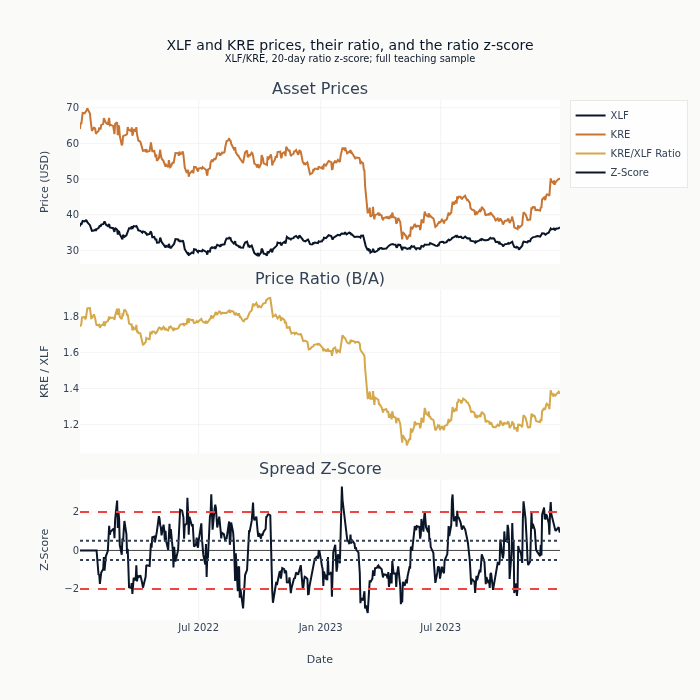

In [31]:
# Add threshold lines and display
if pairs_strategy.zscore_history:
    fig.add_hline(y=2.0, line_dash="dash", line_color=COLORS["negative"], row=3, col=1)
    fig.add_hline(y=-2.0, line_dash="dash", line_color=COLORS["negative"], row=3, col=1)
    fig.add_hline(y=0.5, line_dash="dot", line_color=COLORS["neutral"], row=3, col=1)
    fig.add_hline(y=-0.5, line_dash="dot", line_color=COLORS["neutral"], row=3, col=1)

    fig.update_layout(
        height=700,
        title=(
            "XLF and KRE prices, their ratio, and the ratio z-score"
            "<br><sup>XLF/KRE, 20-day ratio z-score; full teaching sample</sup>"
        ),
        showlegend=True,
    )
    fig.update_yaxes(title_text="Price (USD)", row=1, col=1)
    fig.update_yaxes(title_text="KRE / XLF", row=2, col=1)
    fig.update_yaxes(title_text="Z-Score", row=3, col=1)
    fig.update_xaxes(title_text="Date", row=3, col=1)
    show_plotly_with_alt(
        fig,
        (
            f"Three stacked panels on a shared date axis. The top panel is the {PAIR_A} and "
            f"{PAIR_B} closing prices on one axis. The middle panel is their ratio. The bottom "
            "panel is that ratio's rolling z-score, with dashed lines at the entry bands and "
            "dotted lines at the exit bands. The z-score is taken over a rolling window rather "
            "than the whole sample, so it re-centres as the ratio's level moves, and the three "
            "panels are stacked to show the same dates through each transform the rule applies."
        ),
    )

**Key observation**: The spread signal can be precomputed, but the trade itself
is managed as a stateful object. The strategy opens the lead leg first, sizes
the hedge from the realized lead-leg fill, and unwinds the trade if the hedge
cannot be established quickly. That contingency depends on simulated execution
state, not just on the z-score path.

## Pattern 3: Drawdown Circuit Breaker (Path-Dependent Sizing)

**The idea**: Monitor portfolio drawdown and progressively reduce position sizing
as drawdown deepens. At a critical threshold, halt all new entries entirely.
As the portfolio recovers, gradually resume normal sizing.

**Why a fixed matrix is awkward**: The sizing multiplier at bar N depends on
drawdown through bar N-1, but the realized equity path depends on the sizes used
in prior trades. Equity and exposure co-evolve, so the rule is easiest to write
as a recursive state update rather than as predetermined weights.

### Three Drawdown Zones

Drawdown is measured as a positive loss fraction from the running peak, so a larger number is
a worse position and the zones are read upwards from zero.

| Zone | Drawdown from the peak | Behavior |
|------|------------------------|----------|
| **Normal** | below the caution threshold | Full sizing; the multiplier recovers toward one |
| **Caution** | between the two thresholds | Reduced sizing, interpolated linearly to zero |
| **Halt** | past the halt threshold | No new entries; the multiplier is zero |

The run below sets both thresholds explicitly and the drawdown panel of its figure annotates
each one, so the zone boundaries a run actually used are readable from its own output rather
than fixed in this table.

The state update maps current account drawdown to the next target multiplier.

In [32]:
def _update_circuit_state(self, equity: float) -> None:
    self.peak_equity = max(self.peak_equity, equity)
    drawdown = (self.peak_equity - equity) / self.peak_equity if self.peak_equity else 0.0
    if drawdown < self.caution_threshold:
        self.sizing_multiplier = min(1.0, self.sizing_multiplier + self.recovery_rate)
    elif drawdown < self.halt_threshold:
        range_fraction = (drawdown - self.caution_threshold) / (
            self.halt_threshold - self.caution_threshold
        )
        self.sizing_multiplier = self.reduction_factor * (1 - range_fraction)
    else:
        self.sizing_multiplier = 0.0
    self.multiplier_history.append(self.sizing_multiplier)
    self.drawdown_history.append(drawdown)

The event callback applies the current multiplier only to new entries. Existing
positions still follow their exit signal, which is why the breaker cannot undo
a loss already in progress.

In [33]:
def _circuit_on_data(self, timestamp, data, context, broker):
    equity = broker.get_account_value()
    self._update_circuit_state(equity)
    for asset, bar in data.items():
        signals = bar.get("signals", {})
        signal = signals.get(self.signal_column, 0) if signals else 0
        signal = 0 if signal is None else signal
        if bar.get("close", 0) <= 0:
            continue

        position = broker.get_position(asset)
        if position is None and signal > self.entry_threshold:
            if self.sizing_multiplier <= 0:
                continue
            broker.order_target_percent(asset, self.base_size * self.sizing_multiplier)
        elif position is not None and signal < self.exit_threshold:
            broker.close_position(asset)

The strategy object keeps only the parameters and recursive account state.

In [34]:
class DrawdownCircuitBreakerStrategy(Strategy):
    """Reduce or halt trading when portfolio drawdown exceeds thresholds."""

    _update_circuit_state = _update_circuit_state
    on_data = _circuit_on_data

    def __init__(
        self,
        signal_column: str = "signal",
        entry_threshold: float = 0.01,
        exit_threshold: float = -0.01,
        base_size: float = 0.10,
        caution_threshold: float = 0.05,
        halt_threshold: float = 0.10,
        reduction_factor: float = 0.5,
        recovery_rate: float = 0.01,
    ):
        self.signal_column = signal_column
        self.entry_threshold = entry_threshold
        self.exit_threshold = exit_threshold
        self.base_size = base_size
        self.caution_threshold = caution_threshold
        self.halt_threshold = halt_threshold
        self.reduction_factor = reduction_factor
        self.recovery_rate = recovery_rate
        self.peak_equity = 0.0
        self.sizing_multiplier = 1.0
        self.multiplier_history: list[float] = []
        self.drawdown_history: list[float] = []

### Run Circuit Breaker Strategy

We load SPY daily bars from 2019-08 through 2021-07 (500 trading days). The
window covers calm late-2019, the February–March 2020 COVID crash (peak-to-
trough drawdown of about a third in five weeks), and the subsequent recovery into
2021. An alternating entry/exit signal forces the strategy to consider re-
entry while the equity path is still impaired, which is exactly when the
circuit breaker must override the signal.

In [35]:
crash_prices = _load_single_window(symbol="SPY", start="2019-08-01", n_bars=N_BARS)
crash_signals = make_signals(crash_prices, signal_fn="alternating", lookback=12)
CRASH_SYMBOL = "SPY"

# Circuit breaker strategy
cb_strategy = DrawdownCircuitBreakerStrategy(
    entry_threshold=0.0,
    exit_threshold=0.0,
    base_size=0.30,
    caution_threshold=0.03,
    halt_threshold=0.06,
    reduction_factor=0.5,
    recovery_rate=0.02,
)

feed = DataFeed(prices_df=crash_prices, signals_df=crash_signals)
engine = Engine(feed=feed, strategy=cb_strategy, config=config)
cb_result = engine.run()

# Unprotected baseline (same signals, no circuit breaker)
unprotected = FixedSizeStrategy(size=0.30, entry_threshold=0.0, exit_threshold=0.0)
feed_base = DataFeed(prices_df=crash_prices, signals_df=crash_signals)
engine_base = Engine(feed=feed_base, strategy=unprotected, config=config)
base_result = engine_base.run()

cbm = cb_result.metrics
bm = base_result.metrics

**Drawdown circuit breaker vs unprotected baseline** (same signals, sizing rule
differs once the protected strategy hits the caution / halt thresholds):

In [36]:
pl.DataFrame(
    {
        "metric": ["Total return (%)", "Sharpe ratio", "Max drawdown (%)", "Total trades"],
        "with_breaker": [
            float(cbm["total_return_pct"]),
            float(cbm["sharpe"]),
            float(cbm["max_drawdown_pct"]),
            float(cbm["num_trades"]),
        ],
        "unprotected": [
            float(bm["total_return_pct"]),
            float(bm["sharpe"]),
            float(bm["max_drawdown_pct"]),
            float(bm["num_trades"]),
        ],
    }
)

metric,with_breaker,unprotected
str,f64,f64
"""Total return (%)""",-2.428605,8.555342
"""Sharpe ratio""",-0.246518,0.739241
"""Max drawdown (%)""",7.190078,7.190078
"""Total trades""",7.0,21.0


In [37]:
cb_trades = int(cbm["num_trades"])
base_trades = int(bm["num_trades"])
trade_reduction = 1 - cb_trades / base_trades
halt_bars = sum(np.isclose(value, 0.0) for value in cb_strategy.multiplier_history)
display(
    Markdown(
        f"The breaker completes **{cb_trades} closed trades**, versus **{base_trades}** for the "
        f"unprotected rule, a **{trade_reduction:.0%} reduction**. It blocks new entries on "
        f"**{halt_bars} bars** after the drawdown reaches the {cb_strategy.halt_threshold:.0%} "
        f"halt threshold. Maximum drawdown is **{cbm['max_drawdown_pct']:.2f}%** with the breaker "
        f"and **{bm['max_drawdown_pct']:.2f}%** without it because the first crash leg occurs "
        "while the protected strategy already holds a position."
    )
)

The breaker completes **7 closed trades**, versus **21** for the unprotected rule, a **67% reduction**. It blocks new entries on **345 bars** after the drawdown reaches the 6% halt threshold. Maximum drawdown is **7.19%** with the breaker and **7.19%** without it because the first crash leg occurs while the protected strategy already holds a position.

### Visualize Circuit Breaker Behavior

The key visualization: drawdown zones and the resulting sizing multiplier.

In [38]:
# Prepare circuit breaker visualization data and equity traces
if cb_strategy.multiplier_history and cb_strategy.drawdown_history:
    dates = (
        crash_prices.filter(pl.col("symbol") == CRASH_SYMBOL)
        .sort("timestamp")["timestamp"]
        .to_list()
    )
    n = min(len(dates), len(cb_strategy.multiplier_history))

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights=[0.35, 0.35, 0.30],
        subplot_titles=["Portfolio Equity", "Drawdown (%)", "Sizing Multiplier"],
    )

The first panel compares protected and unprotected account values.

In [39]:
if cb_strategy.multiplier_history and cb_strategy.drawdown_history:
    eq = cb_result.to_equity_dataframe()
    fig.add_trace(
        go.Scatter(
            x=eq["timestamp"].to_list(),
            y=eq["equity"].to_list(),
            name="Equity (Protected)",
            line=dict(color=COLORS["blue"]),
        ),
        row=1,
        col=1,
    )

    eq_base = base_result.to_equity_dataframe()
    fig.add_trace(
        go.Scatter(
            x=eq_base["timestamp"].to_list(),
            y=eq_base["equity"].to_list(),
            name="Equity (Unprotected)",
            line=dict(color=COLORS["neutral"], dash="dash"),
        ),
        row=1,
        col=1,
    )

In [40]:
# Add drawdown and threshold traces
if cb_strategy.multiplier_history and cb_strategy.drawdown_history:
    dd_pct = [-d * 100 for d in cb_strategy.drawdown_history[:n]]
    fig.add_trace(
        go.Scatter(
            x=dates[:n],
            y=dd_pct,
            name="Drawdown",
            fill="tozeroy",
            line=dict(color=COLORS["negative"]),
        ),
        row=2,
        col=1,
    )
    fig.add_hline(
        y=-100 * cb_strategy.caution_threshold,
        line_dash="dash",
        line_color=COLORS["amber"],
        annotation_text=f"Caution ({cb_strategy.caution_threshold:.0%})",
        row=2,
        col=1,
    )
    fig.add_hline(
        y=-100 * cb_strategy.halt_threshold,
        line_dash="dash",
        line_color=COLORS["negative"],
        annotation_text=f"Halt ({cb_strategy.halt_threshold:.0%})",
        row=2,
        col=1,
    )

The final panel makes the recursive exposure control visible.

In [41]:
if cb_strategy.multiplier_history and cb_strategy.drawdown_history:
    fig.add_trace(
        go.Scatter(
            x=dates[:n],
            y=cb_strategy.multiplier_history[:n],
            name="Sizing Multiplier",
            line=dict(color=COLORS["positive"]),
        ),
        row=3,
        col=1,
    )

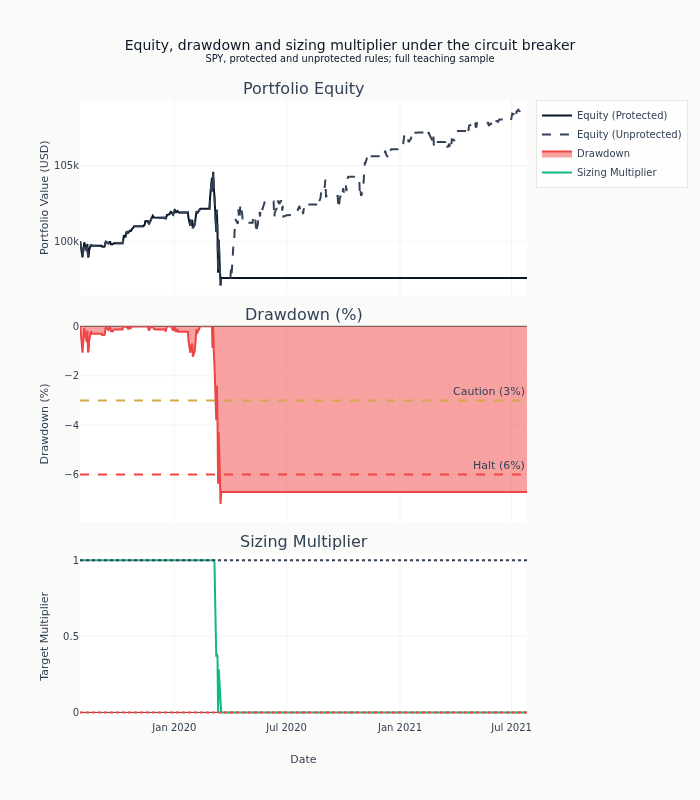

In [42]:
# Add threshold reference lines and display
if cb_strategy.multiplier_history and cb_strategy.drawdown_history:
    fig.add_hline(y=0, line_dash="dot", line_color=COLORS["negative"], row=3, col=1)
    fig.add_hline(y=1, line_dash="dot", line_color=COLORS["neutral"], row=3, col=1)

    fig.update_layout(
        height=800,
        title=(
            "Equity, drawdown and sizing multiplier under the circuit breaker"
            "<br><sup>SPY, protected and unprotected rules; full teaching sample</sup>"
        ),
    )
    fig.update_yaxes(title_text="Portfolio Value (USD)", row=1, col=1)
    fig.update_yaxes(title_text="Drawdown (%)", range=[min(dd_pct) * 1.1, 0], row=2, col=1)
    fig.update_yaxes(title_text="Target Multiplier", range=[-0.05, 1.05], row=3, col=1)
    fig.update_xaxes(title_text="Date", row=3, col=1)
    show_plotly_with_alt(
        fig,
        (
            "Three stacked panels on a shared date axis. The top panel holds two equity curves "
            "built from the same signals, one with the circuit breaker active and one without, so "
            "the only difference between them is the breaker. The middle panel is the protected "
            "rule's drawdown as a negative percentage below zero, against dashed lines at the "
            "caution and halt thresholds drawn with the same sign; the breaker itself compares a "
            "positive loss fraction internally, and the panel negates it so losses read downward. "
            "The bottom panel is the sizing multiplier the breaker applies, which is the mechanism "
            "connecting the other two panels."
        ),
    )

**Key observation**: A new-entry breaker cannot undo losses on a position that
is already open. Once this run exits into cash beyond the halt threshold, equity
cannot recover on its own, so the rule remains halted. A production policy
therefore needs an explicit reset, external-capital, or re-entry protocol. The
lesson is that future actions depend on realized portfolio state, not that a
breaker automatically improves returns.

## Summary: When Sequential State Helps

| Pattern | Static array form | Sequential engine | Why? |
|---------|-------------------|-------------------|------|
| Buy on signal, sell on signal | Straightforward | Also works | Decisions depend only on observable data |
| Equal-weight rebalancing | Straightforward | Also works | Target weights are known once the protocol is fixed |
| Position size adapts to realized P&L | Recursive and awkward | Natural fit | Sizing depends on prior realized outcomes |
| Cross-asset capital coordination | Possible, but bookkeeping-heavy | Natural fit | Fills, cash, and margin couple the legs |
| Equity-path-dependent behavior | Recursive and awkward | Natural fit | Equity and sizing co-evolve |
| Reactive order management | Not a fixed matrix | Natural fit | Fills create new contingent orders |
| Pyramiding (conditional entries) | Not a fixed matrix | Natural fit | Entry N depends on prior entries |

**Rule of thumb**: If the full trading protocol can be precomputed as aligned
arrays, use the array-based path. If later actions depend on mutable portfolio
state, explicit sequential simulation is usually clearer and safer.

## Additional Patterns

The library's `examples/stateful_strategies.py` includes two more patterns not
shown here:

- **Pyramiding**: Add to a position that is already ahead, at unrealized P&L thresholds
- **Grid Trading**: Reactive limit order management where each fill triggers
  new orders at adjacent price levels

See the [Stateful Strategies user guide](https://github.com/stefan-jansen/ml4t-backtest/blob/main/docs/user-guide/stateful-strategies.md)
for all five patterns with code, explanations, and testing guidance.

## Key Takeaways

1. **Array-based backtests are fast because they operate on precomputed arrays**
   and broadcast naturally across parameter grids, but they can consume
   substantial memory when the state space grows.

2. **The important question is not "vectorized or event-driven?" in the
   abstract**. The real question is whether the trading protocol can be fixed
   before execution starts or whether later actions depend on evolving state.

3. **Sequential simulation is often the more natural description of trading**.
   It preserves the loop of observing, updating state, acting, and processing
   outcomes instead of hiding those transitions inside array alignment.

4. **Sequential simulation becomes valuable when fills, realized P&L, equity,**
   or cross-asset coordination feed back into future decisions.

5. **These examples are modeling patterns, not universal library limits**.
   The point is to make state dependence visible and inspectable.

**Next**: Chapter 19 applies these patterns in production risk management.
**Book**: Section 16.3 explains the speed-fidelity spectrum and why
stateful strategies are most naturally expressed as event-driven simulation.